# Credit Card Fraud Detection — Data Cleaning

This notebook prepares the raw dataset for model building. The main tasks are removing duplicate rows, confirming missing values, scaling the `Amount` and `Time` features, and saving the cleaned dataset.

The cleaned dataset will be saved as:

`data/creditcard_cleaned.csv`

## 1. Imports & Load Data

We import the required libraries, load the helper functions from `utils.py`, and load the raw dataset from the `data` folder.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add current project folder to Python path
sys.path.append(".")

from utils import load_data, preprocess_data

# Chart settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load raw dataset
df_raw = load_data("data/creditcard.csv")

print(f"Raw dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

df_raw.head()

Raw dataset loaded: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
print("Dataset Shape")
print("-------------")
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")

print("\nClass Distribution")
print("------------------")
print(df_raw["Class"].value_counts())

print(f"\nFraud Rate: {df_raw['Class'].mean() * 100:.4f}%")

Dataset Shape
-------------
Rows    : 284,807
Columns : 31

Class Distribution
------------------
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate: 0.1727%


## 2. Missing Values and Duplicate Rows

In this section, we check whether the dataset contains missing values and duplicate rows. Missing values can affect model training, while duplicate records can bias the model and evaluation results.

From the EDA stage, we identified that the dataset has no missing values but contains duplicate rows. Therefore, duplicate rows will be removed in this notebook.

In [16]:
# Check missing values
missing_values = df_raw.isnull().sum()
total_missing = missing_values.sum()

print("Missing Values")
print("--------------")
print(f"Total missing values: {total_missing}")

# Check duplicate rows
duplicate_count = df_raw.duplicated().sum()

print("\nDuplicate Rows")
print("--------------")
print(f"Duplicate rows found: {duplicate_count:,}")

# Remove duplicate rows
df_clean = df_raw.drop_duplicates().copy()

print("\nAfter Removing Duplicates")
print("-------------------------")
print(f"Original dataset shape : {df_raw.shape}")
print(f"Cleaned dataset shape  : {df_clean.shape}")
print(f"Rows removed           : {df_raw.shape[0] - df_clean.shape[0]:,}")
print(f"Remaining duplicates   : {df_clean.duplicated().sum()}")

Missing Values
--------------
Total missing values: 0

Duplicate Rows
--------------
Duplicate rows found: 1,081

After Removing Duplicates
-------------------------
Original dataset shape : (284807, 31)
Cleaned dataset shape  : (283726, 31)
Rows removed           : 1,081
Remaining duplicates   : 0


In [17]:
duplicate_summary = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Removing Duplicates"],
    "Rows": [df_raw.shape[0], df_clean.shape[0]],
    "Columns": [df_raw.shape[1], df_clean.shape[1]],
    "Missing Values": [df_raw.isnull().sum().sum(), df_clean.isnull().sum().sum()],
    "Duplicate Rows": [df_raw.duplicated().sum(), df_clean.duplicated().sum()],
    "Legitimate Transactions": [
        (df_raw["Class"] == 0).sum(),
        (df_clean["Class"] == 0).sum()
    ],
    "Fraud Transactions": [
        (df_raw["Class"] == 1).sum(),
        (df_clean["Class"] == 1).sum()
    ],
    "Fraud Rate (%)": [
        round(df_raw["Class"].mean() * 100, 4),
        round(df_clean["Class"].mean() * 100, 4)
    ]
})

display(duplicate_summary)

,Stage,Rows,Columns,Missing Values,Duplicate Rows,Legitimate Transactions,Fraud Transactions,Fraud Rate (%)
0,Before Cleaning,284807,31,0,1081,284315,492,0.1727
1,After Removing Duplicates,283726,31,0,0,283253,473,0.1667


### Missing Values and Duplicate Rows Interpretation

The dataset does not contain any missing values, so no missing value treatment is required.

However, the dataset contains 1,081 duplicate rows. These duplicate rows were removed to avoid repeated records affecting the machine learning model.

After removing duplicates, the dataset size was reduced from 284,807 rows to 283,726 rows. The class imbalance still remains severe, which means model evaluation must still focus on metrics such as Precision, Recall, F1-score, ROC-AUC, and confusion matrix rather than accuracy alone.

## 3. Confirm Cleaned Dataset Status

After removing duplicate rows, we confirm that the cleaned dataset has no missing values and check the updated class distribution.

In [18]:
missing = df_clean.isnull().sum()

print("Missing values per column:")
print("--------------------------")

if missing.any():
    print(missing[missing > 0])
else:
    print("None — dataset is complete.")

print("\nClass distribution after removing duplicates:")
print("---------------------------------------------")
print(df_clean["Class"].value_counts())

print("\nClass percentage after removing duplicates:")
print("-------------------------------------------")
print((df_clean["Class"].value_counts(normalize=True) * 100).round(4))

print(f"\nFraud rate after removing duplicates: {df_clean['Class'].mean() * 100:.4f}%")

Missing values per column:
--------------------------
None — dataset is complete.

Class distribution after removing duplicates:
---------------------------------------------
Class
0    283253
1       473
Name: count, dtype: int64

Class percentage after removing duplicates:
-------------------------------------------
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

Fraud rate after removing duplicates: 0.1667%


## 4. Scale Amount and Time

`Amount` is highly right-skewed with extreme outliers, making standard Z-score scaling less suitable. `RobustScaler` is used because it scales using the median and interquartile range, making it more resistant to outliers.

`Time` is also scaled so it is on a comparable scale with the other features.

The PCA-transformed features `V1` to `V28` are already processed by the dataset creators, so they are left unchanged.

In [19]:
print("Before Scaling — Amount and Time Statistics")
print("-------------------------------------------")

display(df_clean[["Amount", "Time"]].describe().round(3))

Before Scaling — Amount and Time Statistics
-------------------------------------------


,Amount,Time
count,283726.000,283726.000
mean,88.473,94811.078
std,250.399,47481.048
min,0.000,0.000
25%,5.600,54204.750
50%,22.000,84692.500
75%,77.510,139298.000
max,25691.160,172792.000


In [20]:
# Apply preprocessing to scale only Amount and Time
df_processed = preprocess_data(df_clean)

print("Scaling completed successfully.")
print(f"Processed dataset shape: {df_processed.shape}")

print("\nAfter Scaling — Amount and Time Statistics")
print("-----------------------------------------")
display(df_processed[["Amount", "Time"]].describe().round(3))

Scaling completed successfully.
Processed dataset shape: (283726, 31)

After Scaling — Amount and Time Statistics
-----------------------------------------


,Amount,Time
count,283726.000,283726.000
mean,0.924,0.119
std,3.482,0.558
min,-0.306,-0.995
25%,-0.228,-0.358
50%,0.000,0.000
75%,0.772,0.642
max,356.962,1.035


In [21]:
v_cols = [f"V{i}" for i in range(1, 29)]

v_features_unchanged = df_clean[v_cols].equals(df_processed[v_cols])

print("Are V1 to V28 unchanged after preprocessing?")
print(v_features_unchanged)

Are V1 to V28 unchanged after preprocessing?
True


In [22]:
scaling_comparison = pd.DataFrame({
    "Feature": ["Amount", "Time"],
    "Before Mean": [
        df_clean["Amount"].mean(),
        df_clean["Time"].mean()
    ],
    "Before Median": [
        df_clean["Amount"].median(),
        df_clean["Time"].median()
    ],
    "Before Std": [
        df_clean["Amount"].std(),
        df_clean["Time"].std()
    ],
    "After Mean": [
        df_processed["Amount"].mean(),
        df_processed["Time"].mean()
    ],
    "After Median": [
        df_processed["Amount"].median(),
        df_processed["Time"].median()
    ],
    "After Std": [
        df_processed["Amount"].std(),
        df_processed["Time"].std()
    ]
})

display(scaling_comparison.round(4))

,Feature,Before Mean,Before Median,Before Std,After Mean,After Median,After Std
0,Amount,88.4727,22.0,250.3994,0.9244,0.0,3.4821
1,Time,94811.0776,84692.5,47481.0479,0.1189,0.0,0.5580


### Scaling Interpretation

Only the `Amount` and `Time` columns were scaled during preprocessing.

`RobustScaler` was used because the `Amount` feature is highly skewed and contains outliers. RobustScaler is suitable because it uses the median and interquartile range instead of the mean and standard deviation.

The PCA-transformed features `V1` to `V28` were not scaled again because they were already transformed by the dataset creators.

After scaling, the dataset is better prepared for machine learning model training.

## 5. Before / After Scaling Visualisation

This visualization compares the `Amount` and `Time` distributions before and after applying RobustScaler. The shape of the distributions is mostly preserved, but the values are transformed onto a more suitable scale for machine learning.

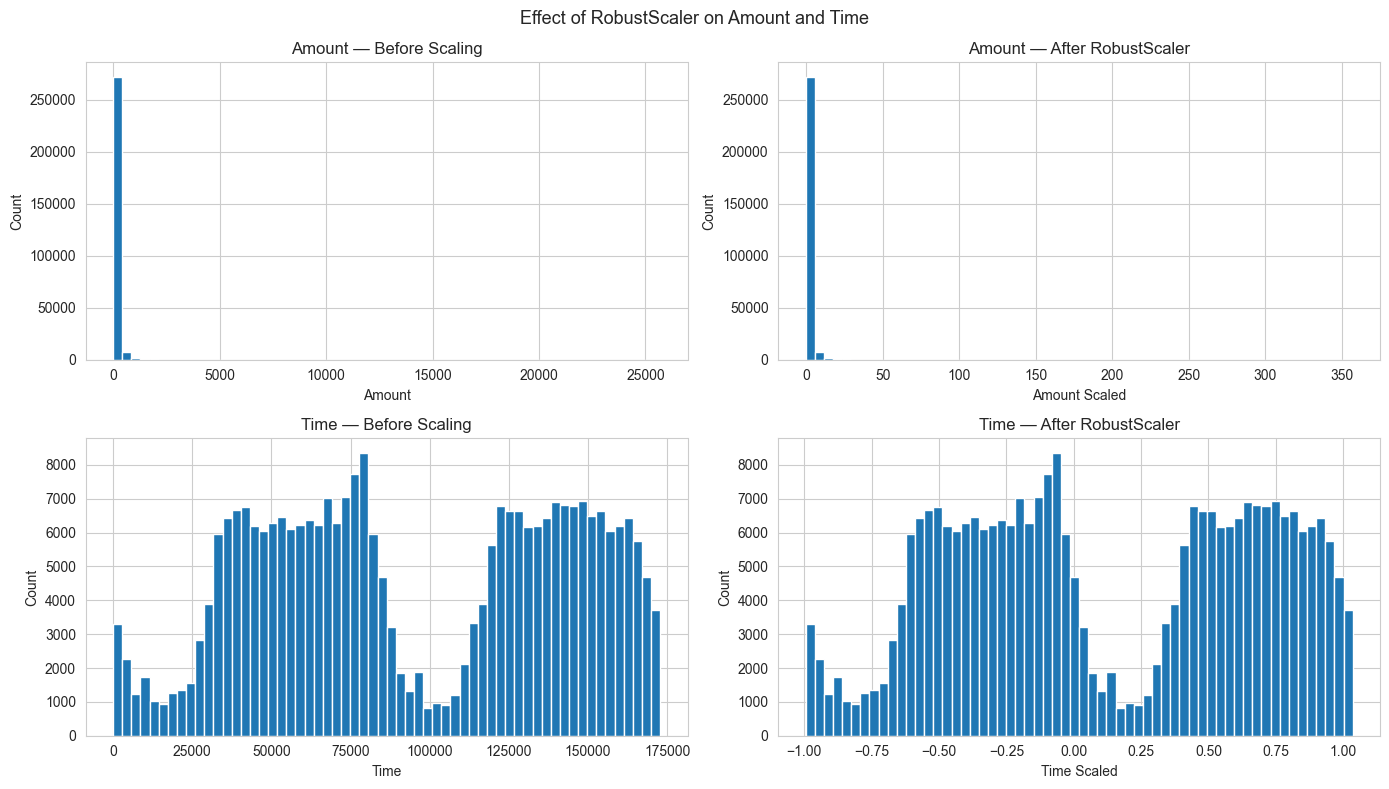

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(["Amount", "Time"]):
    
    # Before scaling
    axes[i, 0].hist(
        df_clean[col],
        bins=60,
        edgecolor="white"
    )
    axes[i, 0].set_title(f"{col} — Before Scaling")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    # After scaling
    axes[i, 1].hist(
        df_processed[col],
        bins=60,
        edgecolor="white"
    )
    axes[i, 1].set_title(f"{col} — After RobustScaler")
    axes[i, 1].set_xlabel(f"{col} Scaled")
    axes[i, 1].set_ylabel("Count")

plt.suptitle("Effect of RobustScaler on Amount and Time", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Verify & Save Cleaned Dataset

Final checks are performed before saving the cleaned dataset. We confirm the correct shape, zero missing values, zero duplicate rows, and the final class distribution.

The cleaned CSV is saved to:

`data/creditcard_cleaned.csv`

In [24]:
# Final checks before saving

assert df_processed.isnull().sum().sum() == 0, "Missing values found!"
assert df_processed.duplicated().sum() == 0, "Duplicate rows found!"
assert df_processed["Class"].nunique() == 2, "Target should be binary!"

print("Final Cleaned Dataset Check")
print("---------------------------")
print(f"Final dataset shape : {df_processed.shape}")
print(f"Missing values      : {df_processed.isnull().sum().sum()}")
print(f"Duplicate rows      : {df_processed.duplicated().sum()}")
print("\nClass distribution:")
print(df_processed["Class"].value_counts())
print(f"\nFraud rate          : {df_processed['Class'].mean() * 100:.4f}%")

display(df_processed.head())

Final Cleaned Dataset Check
---------------------------
Final dataset shape : (283726, 31)
Missing values      : 0
Duplicate rows      : 0

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate          : 0.1667%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.774718,0
1,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.268530,0
2,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.959811,0
3,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.411487,0
4,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.667362,0


In [25]:
# Create data folder if it does not exist
os.makedirs("data", exist_ok=True)

# Save the final processed dataset
out_path = "data/creditcard_cleaned.csv"

df_processed.to_csv(out_path, index=False)

print("Cleaned dataset saved successfully.")
print(f"File saved at: {out_path}")
print(f"Saved dataset shape: {df_processed.shape}")

Cleaned dataset saved successfully.
File saved at: data/creditcard_cleaned.csv
Saved dataset shape: (283726, 31)


In [26]:
# Verify saved file
saved_df = pd.read_csv("data/creditcard_cleaned.csv")

print("Saved file loaded successfully.")
print(f"Saved file shape: {saved_df.shape}")
print(f"Missing values   : {saved_df.isnull().sum().sum()}")
print(f"Duplicate rows   : {saved_df.duplicated().sum()}")
print(f"Fraud count      : {(saved_df['Class'] == 1).sum():,}")
print(f"Legit count      : {(saved_df['Class'] == 0).sum():,}")
print(f"Fraud rate       : {saved_df['Class'].mean() * 100:.4f}%")

display(saved_df.head())

Saved file loaded successfully.
Saved file shape: (283726, 31)
Missing values   : 0
Duplicate rows   : 0
Fraud count      : 473
Legit count      : 283,253
Fraud rate       : 0.1667%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.774718,0
1,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.268530,0
2,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.959811,0
3,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.411487,0
4,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.667362,0


## Data Cleaning Summary

The data cleaning and preprocessing stage completed the following tasks:

1. The raw dataset was loaded from `data/creditcard.csv`.
2. Missing values were checked, and no missing values were found.
3. Duplicate rows were removed.
4. The dataset was reduced from 284,807 rows to 283,726 rows.
5. The `Amount` and `Time` columns were scaled using RobustScaler.
6. The PCA-transformed features `V1` to `V28` were left unchanged.
7. The cleaned dataset was saved as `data/creditcard_cleaned.csv`.

The cleaned dataset is now ready for machine learning model building.